In [10]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [11]:
titanic= sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
features= ["sex", "age", "fare","pclass", "embarked"]
target= "survived"

imp_median= SimpleImputer(strategy= "median")
titanic[["age"]]= imp_median.fit_transform(titanic[["age"]])

imp_freq= SimpleImputer(strategy= "most_frequent")
titanic[["embarked"]]= imp_freq.fit_transform(titanic[["embarked"]])

le= LabelEncoder()

titanic["sex"]= le.fit_transform(titanic["sex"])
titanic["embarked"]= le.fit_transform(titanic["embarked"])

X= titanic[features]
y= titanic[target]

X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state= 42)

In [13]:
model= DecisionTreeClassifier(max_depth=4)
model.fit(X_train, y_train)
y_pred_train= model.predict(X_train)
y_pred_test= model.predict(X_test)
print("training Accuracy:", accuracy_score(y_train, y_pred_train))
print("testing Accuracy:", accuracy_score(y_test, y_pred_test))

training Accuracy: 0.8398876404494382
testing Accuracy: 0.7988826815642458


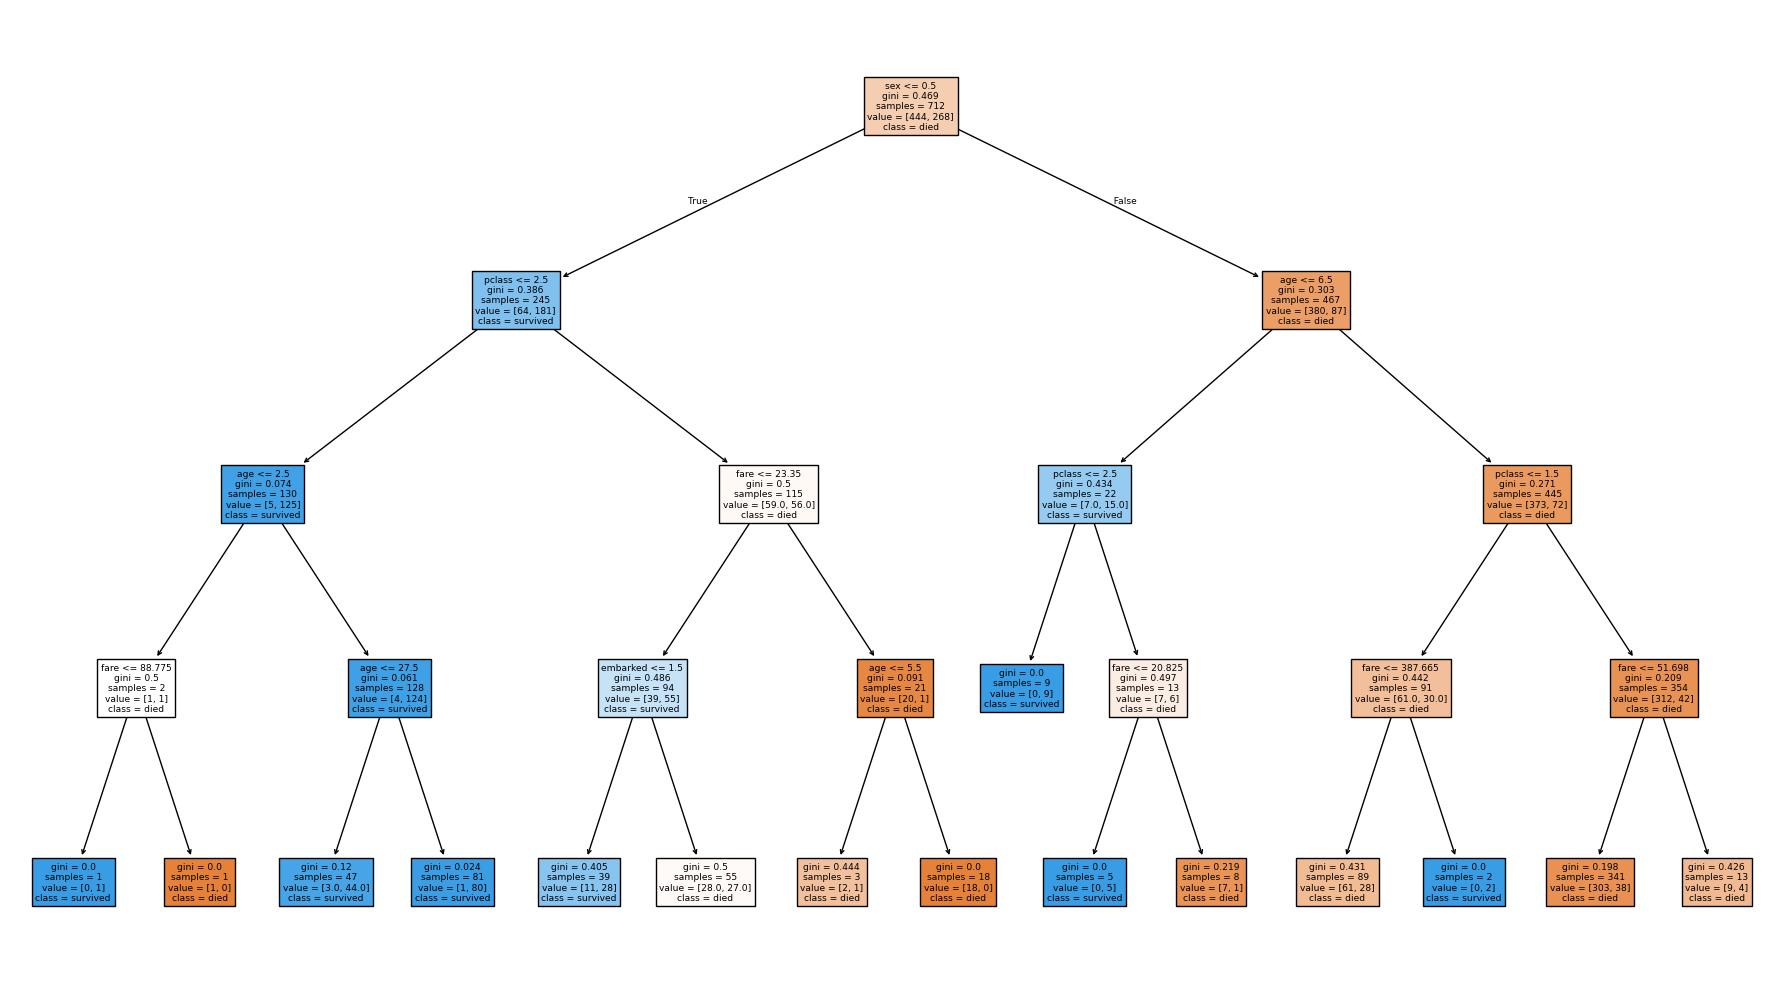

In [14]:
from sklearn.tree import plot_tree
plt.figure(figsize= (18, 10))
plot_tree(model, feature_names= X.columns, class_names= ["died", "survived"], filled= True)

plt.tight_layout()

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf= RandomForestClassifier(n_estimators= 501, oob_score= True, max_depth=4)

rf.fit(X_train, y_train)
y_pred= rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("OOB score:", rf.oob_score_)

Accuracy: 0.8156424581005587
OOB score: 0.8286516853932584


In [18]:
from sklearn.ensemble import BaggingClassifier
base_model= DecisionTreeClassifier()
bagging= BaggingClassifier(base_model, n_estimators= 201)
bagging.fit(X_train, y_train)
y_pred_bagging= bagging.predict(X_test)
print("Accuracy_score:", accuracy_score(y_test, y_pred_bagging))

Accuracy_score: 0.8044692737430168


In [19]:
from sklearn.linear_model import LogisticRegression
log_reg= LogisticRegression()
bagging= BaggingClassifier(log_reg, n_estimators=201)
log_reg.fit(X_train, y_train)
y_pred_log= log_reg.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_log))

Accuracy: 0.7988826815642458
